In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use("seaborn-v0_8")
sns.set_palette("deep")


In [17]:
df = pd.read_csv("../data/raw/creditcard.csv")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (250744, 50)


,transaction_id,user_id,device_id,merchant_id,session_id,txn_time,txn_amount,txn_currency,txn_hour,txn_day_of_week,...,avg_txn_amount_90d,dormant_account_flag,new_payee_added_24h,email_change_7d,phone_change_7d,geo_distance_last_login,impossible_travel_flag,login_hour_deviation,session_duration_zscore,fraud_label
0,1,16795,8512,3450,93177,26-04-2024 9:41,75.985614,USD,9,4,...,14.933552,0,0,0,0,1.460731,0,4.129832,-1.463200,0
1,2,1860,4155,3552,461632,21-01-2024 6:24,22.339063,CAD,6,6,...,9.163966,0,0,0,0,81.059175,0,0.534457,-0.823666,0
2,3,39158,12806,3480,261998,05-01-2024 13:16,113.278392,USD,13,4,...,229.594905,0,0,0,0,65.769144,0,-0.484853,0.443232,0
3,4,12284,3770,3273,266224,14-05-2024 23:53,45.821144,CAD,23,1,...,237.550036,0,0,0,0,44.559035,0,-1.228798,2.307250,0
4,5,7265,11772,3353,419057,20-02-2024 1:37,120.520888,CAD,1,1,...,15.370694,0,1,0,0,85.293193,0,3.144927,-1.884058,0


In [18]:
df.columns = df.columns.str.strip()

print("Columns:")
print(df.columns.tolist())

Columns:
['transaction_id', 'user_id', 'device_id', 'merchant_id', 'session_id', 'txn_time', 'txn_amount', 'txn_currency', 'txn_hour', 'txn_day_of_week', 'is_weekend_flag', 'high_amount_flag', 'txn_amount_zscore', 'cross_border_flag', 'merchant_category', 'txn_count_1h', 'txn_count_24h', 'txn_count_7d', 'sum_amount_24h', 'distinct_merchant_24h', 'failed_login_count_1h', 'password_reset_24h', 'address_change_7d', 'device_change_7d', 'rapid_fire_flag', 'device_user_count', 'device_first_seen_days', 'device_risk_score', 'emulator_flag', 'jailbroken_flag', 'proxy_flag', 'ip_risk_score', 'browser_change_flag', 'fingerprint_mismatch_flag', 'shared_device_cluster_size', 'account_age_days', 'kyc_level', 'credit_limit', 'credit_utilization_ratio', 'past_fraud_flag', 'avg_txn_amount_90d', 'dormant_account_flag', 'new_payee_added_24h', 'email_change_7d', 'phone_change_7d', 'geo_distance_last_login', 'impossible_travel_flag', 'login_hour_deviation', 'session_duration_zscore', 'fraud_label']


In [19]:
print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False).head(10))




Data Types:
transaction_id                  int64
user_id                         int64
device_id                       int64
merchant_id                     int64
session_id                      int64
txn_time                          str
txn_amount                    float64
txn_currency                      str
txn_hour                        int64
txn_day_of_week                 int64
is_weekend_flag                 int64
high_amount_flag                int64
txn_amount_zscore             float64
cross_border_flag               int64
merchant_category                 str
txn_count_1h                    int64
txn_count_24h                   int64
txn_count_7d                    int64
sum_amount_24h                float64
distinct_merchant_24h           int64
failed_login_count_1h           int64
password_reset_24h              int64
address_change_7d               int64
device_change_7d                int64
rapid_fire_flag                 int64
device_user_count               int64

In [20]:
print("Fraud Distribution:")
print(df['fraud_label'].value_counts())

fraud_rate = df['fraud_label'].mean()
print("\nFraud Rate:", round(fraud_rate * 100, 4), "%")


Fraud Distribution:
fraud_label
0    236888
1     13856
Name: count, dtype: int64

Fraud Rate: 5.526 %


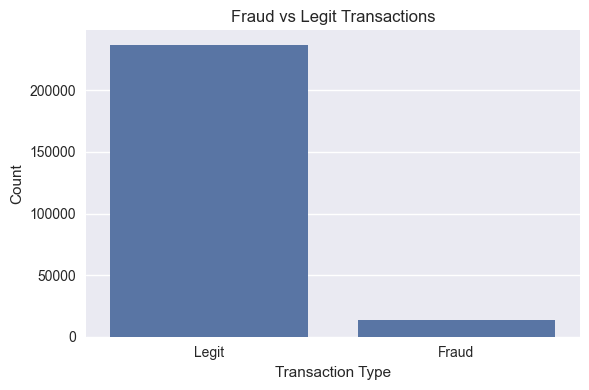

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(x='fraud_label', data=df)

plt.title("Fraud vs Legit Transactions")
plt.xticks([0,1], ["Legit", "Fraud"])
plt.xlabel("Transaction Type")
plt.ylabel("Count")

plt.tight_layout()

# Save for README
plt.savefig("../reports/figures/class_distribution.png")

plt.show()


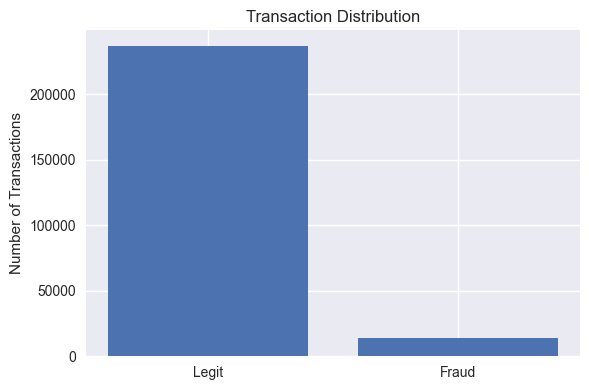

In [22]:
fraud_counts = df['fraud_label'].value_counts()

plt.figure(figsize=(6,4))

bars = plt.bar(["Legit", "Fraud"], fraud_counts.values)

plt.title("Transaction Distribution")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.savefig("../reports/figures/fraud_distribution_simple.png")

plt.show()


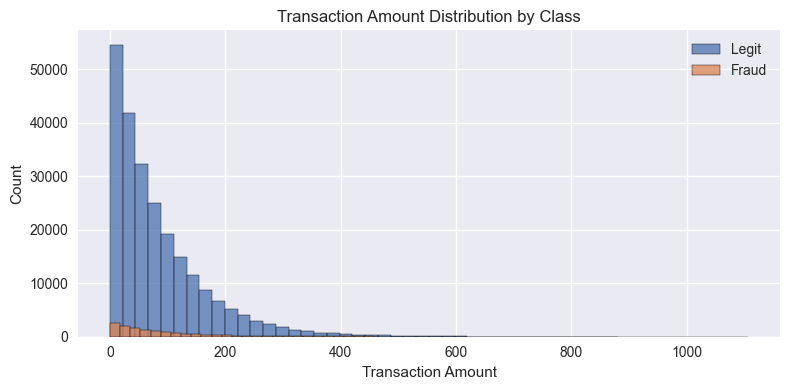

In [23]:
plt.figure(figsize=(8,4))

sns.histplot(df[df['fraud_label']==0]['txn_amount'], bins=50, label="Legit", kde=False)
sns.histplot(df[df['fraud_label']==1]['txn_amount'], bins=50, label="Fraud", kde=False)

plt.legend()
plt.title("Transaction Amount Distribution by Class")
plt.xlabel("Transaction Amount")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig("../reports/figures/amount_distribution.png")

plt.show()


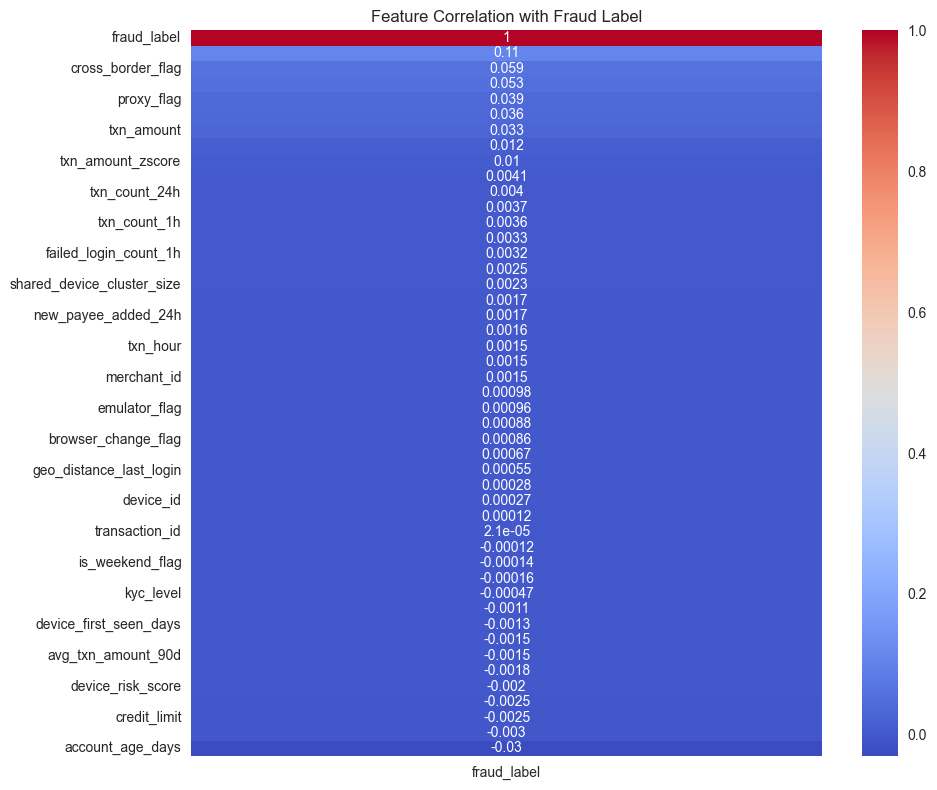

In [24]:
plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(corr[['fraud_label']].sort_values(by='fraud_label', ascending=False),
           annot=True,
           cmap="coolwarm")

plt.title("Feature Correlation with Fraud Label")
plt.tight_layout()
plt.savefig("../reports/figures/fraud_correlation.png")

plt.show()
